In [2]:
# ============================================
# CS3807 - Deep Learning Laboratory
# Experiment 4
# Comparative Study of Deep CNN Architectures
# Using Transfer Learning
# ============================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.applications import VGG16

from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    Input
)

from tensorflow.keras.models import Model

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import time

print("TensorFlow Version:", tf.__version__)
print("NumPy Version:", np.__version__)

TensorFlow Version: 2.20.0
NumPy Version: 2.1.3


In [3]:
# ============================================
# Task 1: Load CIFAR-10 Dataset
# ============================================

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Training Images :", X_train.shape)
print("Training Labels :", y_train.shape)

print("Testing Images  :", X_test.shape)
print("Testing Labels  :", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1864s 11us/step
Training Images : (50000, 32, 32, 3)
Training Labels : (50000, 1)
Testing Images  : (10000, 32, 32, 3)
Testing Labels  : (10000, 1)


In [4]:
# ============================================
# CIFAR-10 Class Names
# ============================================

class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

print("Number of Classes :", len(class_names))
print("Classes :", class_names)

Number of Classes : 10
Classes : ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']


In [5]:
# ============================================
# Normalize Pixel Values
# ============================================

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Minimum pixel value :", X_train.min())
print("Maximum pixel value :", X_train.max())

Minimum pixel value : 0.0
Maximum pixel value : 1.0


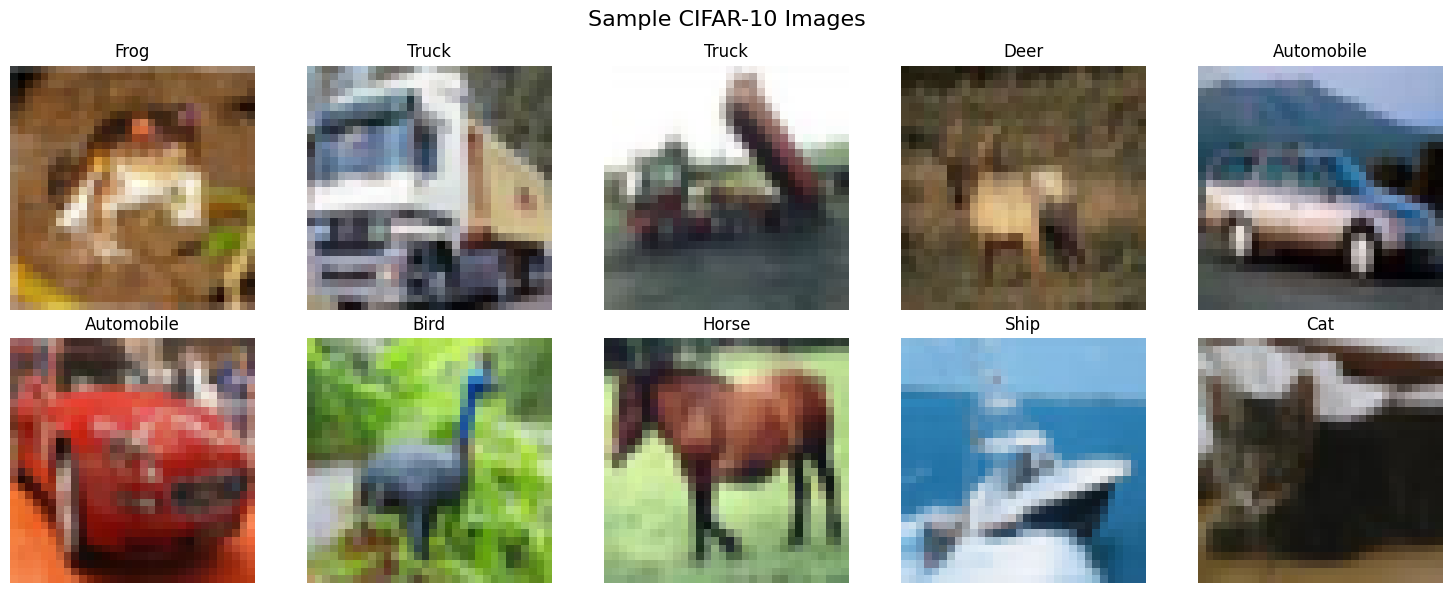

In [6]:
# ============================================
# Display 10 Sample CIFAR-10 Images
# ============================================

plt.figure(figsize=(15, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.suptitle("Sample CIFAR-10 Images", fontsize=16)
plt.tight_layout()
plt.show()

In [7]:
# ============================================
# One-Hot Encode Labels
# ============================================

y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

print("Original Training Labels Shape :", y_train.shape)
print("Encoded Training Labels Shape  :", y_train_cat.shape)

print("Original Testing Labels Shape  :", y_test.shape)
print("Encoded Testing Labels Shape   :", y_test_cat.shape)

Original Training Labels Shape : (50000, 1)
Encoded Training Labels Shape  : (50000, 10)
Original Testing Labels Shape  : (10000, 1)
Encoded Testing Labels Shape   : (10000, 10)


In [8]:
# ============================================
# Task 2: Prepare CIFAR-10 for VGG16
# ============================================

IMG_SIZE = 224
BATCH_SIZE = 32

# Create TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices(
    (X_train, y_train_cat)
)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (X_test, y_test_cat)
)

# Resize images batch-by-batch
def resize_images(images, labels):
    images = tf.image.resize(
        images,
        (IMG_SIZE, IMG_SIZE)
    )
    return images, labels

train_dataset = (
    train_dataset
    .shuffle(10000)
    .batch(BATCH_SIZE)
    .map(resize_images, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    test_dataset
    .batch(BATCH_SIZE)
    .map(resize_images, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Original CIFAR-10 image size : 32 x 32 x 3")
print("VGG16 input image size       : 224 x 224 x 3")
print("Images are resized batch-by-batch.")

Original CIFAR-10 image size : 32 x 32 x 3
VGG16 input image size       : 224 x 224 x 3
Images are resized batch-by-batch.


In [9]:
# ============================================
# Load Pre-trained VGG16
# ============================================

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

print("VGG16 loaded successfully.")
print("Number of layers:", len(base_model.layers))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG16 loaded successfully.
Number of layers: 19


In [10]:
# ============================================
# Freeze Pre-trained Layers
# ============================================

base_model.trainable = False

print("Trainable status of VGG16 layers:")

for layer in base_model.layers[:5]:
    print(layer.name, "->", layer.trainable)

print("\nAll convolutional base layers are frozen.")

Trainable status of VGG16 layers:
input_layer -> False
block1_conv1 -> False
block1_conv2 -> False
block1_pool -> False
block2_conv1 -> False

All convolutional base layers are frozen.


In [11]:
# ============================================
# Add New Classification Head
# ============================================

inputs = Input(shape=(224, 224, 3))

x = base_model(inputs, training=False)

x = GlobalAveragePooling2D()(x)

x = Dense(
    128,
    activation='relu'
)(x)

x = Dropout(0.5)(x)

outputs = Dense(
    10,
    activation='softmax'
)(x)

transfer_model = Model(
    inputs=inputs,
    outputs=outputs
)

print("Transfer learning model created successfully.")

Transfer learning model created successfully.


In [12]:
# ============================================
# Model Summary
# ============================================

transfer_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,781,642 (56.39 MB)

 Trainable params: 66,954 (261.54 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [13]:
# ============================================
# Task 3: Compile Transfer Learning Model
# ============================================

learning_rate = 0.001

optimizer = tf.keras.optimizers.Adam(
    learning_rate=learning_rate
)

transfer_model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully.")
print("Optimizer       : Adam")
print("Learning Rate   :", learning_rate)
print("Loss Function   : Categorical Cross Entropy")
print("Metric          : Accuracy")

Model compiled successfully.
Optimizer       : Adam
Learning Rate   : 0.001
Loss Function   : Categorical Cross Entropy
Metric          : Accuracy


In [14]:
# ============================================
# Train Transfer Learning Model
# ============================================

EPOCHS = 10

start_time = time.time()

history = transfer_model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS
)

training_time = time.time() - start_time

print("\nTraining completed.")
print("Training Time: {:.2f} seconds".format(training_time))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 377s 232ms/step - accuracy: 0.3537 - loss: 1.7916 - val_accuracy: 0.4968 - val_loss: 1.4858
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 361s 231ms/step - accuracy: 0.4616 - loss: 1.5097 - val_accuracy: 0.5419 - val_loss: 1.3199
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 361s 231ms/step - accuracy: 0.4934 - loss: 1.4137 - val_accuracy: 0.5600 - val_loss: 1.2520
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 361s 231ms/step - accuracy: 0.5171 - loss: 1.3600 - val_accuracy: 0.5691 - val_loss: 1.2213
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 361s 231ms/step - accuracy: 0.5320 - loss: 1.3242 - val_accuracy: 0.5905 - val_loss: 1.1739
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 362s 232ms/step - accuracy: 0.5415 - loss: 1.2985 - val_accuracy: 0.5877 - val_loss: 1.1670
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 362s 232ms/step - accuracy: 0.5501 - loss: 1.2806 - val_accuracy: 0.6078 - val_loss: 1.1331
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 361s 231ms/step - ac

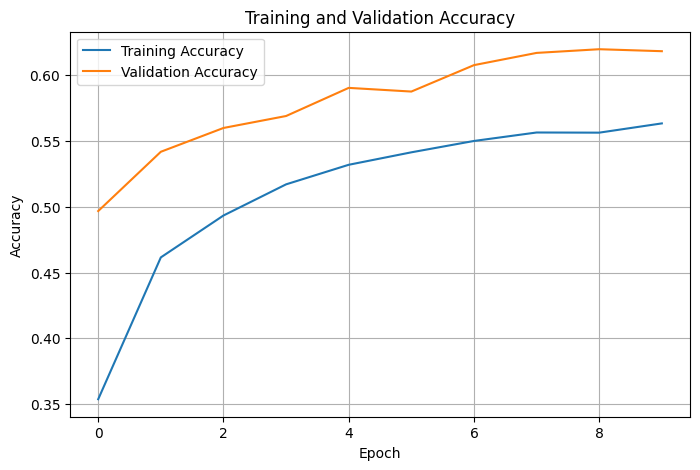

In [15]:
# ============================================
# Plot Training and Validation Accuracy
# ============================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

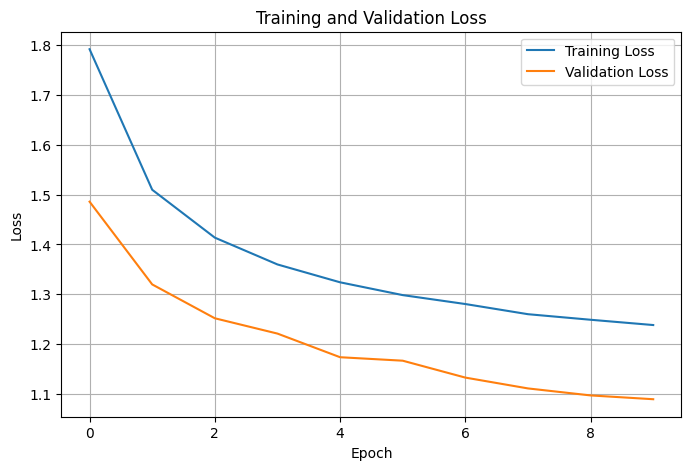

In [16]:
# ============================================
# Plot Training and Validation Loss
# ============================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
# ============================================
# Task 5: Initial Model Evaluation
# ============================================

test_loss, test_accuracy = transfer_model.evaluate(
    test_dataset,
    verbose=1
)

print("\nInitial Model Performance")
print("-------------------------")
print("Test Loss     :", test_loss)
print("Test Accuracy :", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 60s 193ms/step - accuracy: 0.6184 - loss: 1.0897

Initial Model Performance
-------------------------
Test Loss     : 1.0897103548049927
Test Accuracy : 0.618399977684021


In [18]:
# ============================================
# Task 5: Model Evaluation - Generate Predictions
# ============================================

y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = transfer_model.predict(images, verbose=0)

    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Predictions generated successfully.")
print("Number of test samples:", len(y_true))

Predictions generated successfully.
Number of test samples: 10000


In [34]:
# ============================================
# Task 5: Model Evaluation - Performance Metrics
# ============================================

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print("============================================")
print("Initial Transfer Learning Performance")
print("============================================")
print("Accuracy  :", accuracy)
print("Precision :", precision)
print("Recall    :", recall)
print("F1-Score  :", f1)

Initial Transfer Learning Performance
Accuracy  : 0.6184
Precision : 0.6153451074851956
Recall    : 0.6184
F1-Score  : 0.6105016589595283


In [35]:
# ============================================
# Task 5: Model Evaluation - Classification Report
# ============================================

print("============================================")
print("Classification Report")
print("============================================")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0
    )
)

Classification Report
              precision    recall  f1-score   support

    Airplane       0.73      0.68      0.71      1000
  Automobile       0.66      0.81      0.72      1000
        Bird       0.55      0.51      0.53      1000
         Cat       0.50      0.26      0.34      1000
        Deer       0.58      0.48      0.53      1000
         Dog       0.47      0.60      0.53      1000
        Frog       0.58      0.70      0.64      1000
       Horse       0.63      0.67      0.65      1000
        Ship       0.75      0.75      0.75      1000
       Truck       0.70      0.73      0.72      1000

    accuracy                           0.62     10000
   macro avg       0.62      0.62      0.61     10000
weighted avg       0.62      0.62      0.61     10000



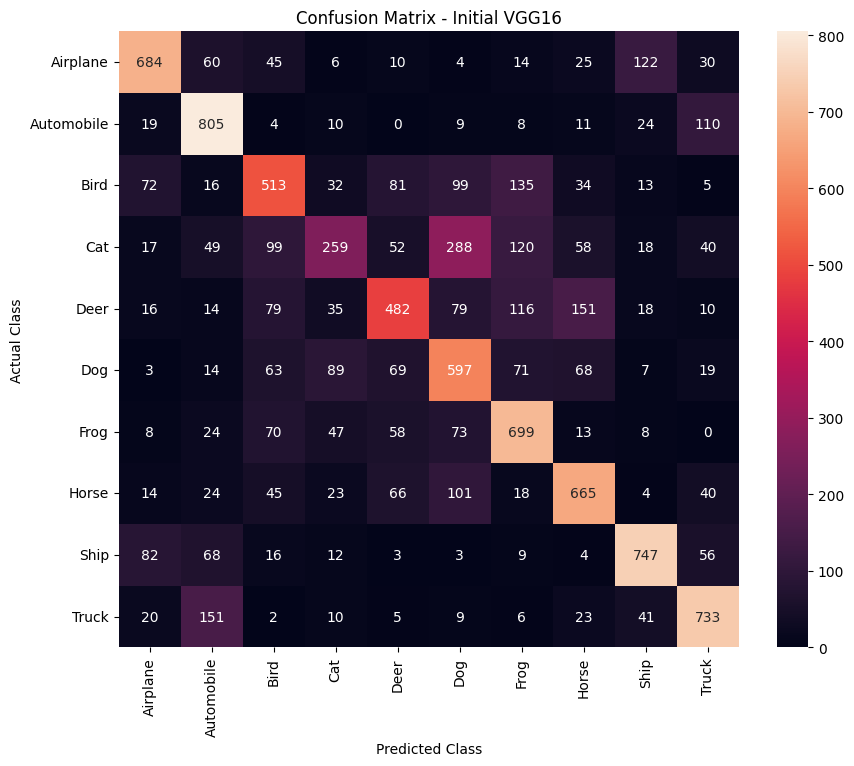

In [19]:
# ============================================
# Task 5: Model Evaluation - Confusion Matrix
# ============================================

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - Initial VGG16")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

In [37]:
# ============================================
# Task 5: Results - Before Fine Tuning
# ============================================

print("Training Accuracy :", history.history["accuracy"][-1])
print("Training Time     :", training_time, "seconds")
print("Total Parameters  :", transfer_model.count_params())

Training Accuracy : 0.563480019569397
Training Time     : 3628.8772699832916 seconds
Total Parameters  : 14781642


In [20]:
# ============================================
# Task 4: Fine Tuning - Unfreeze Last Convolution Block
# ============================================

base_model.trainable = True

# Freeze all layers first
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze only the last convolution block
for layer in base_model.layers:
    if layer.name.startswith("block5"):
        layer.trainable = True

print("Fine-tuning configuration:")
print("--------------------------------")

for layer in base_model.layers:
    if layer.name.startswith("block5"):
        print(layer.name, "->", layer.trainable)

Fine-tuning configuration:
--------------------------------
block5_conv1 -> True
block5_conv2 -> True
block5_conv3 -> True
block5_pool -> True


In [21]:
# ============================================
# Task 4: Fine Tuning - Model Summary
# ============================================

transfer_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,915,552 (56.90 MB)

 Trainable params: 7,146,378 (27.26 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

 Optimizer params: 133,910 (523.09 KB)

In [22]:
# ============================================
# Task 4: Fine Tuning - Compile Model
# ============================================

fine_tune_learning_rate = 0.0001

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=fine_tune_learning_rate
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Fine-tuning model compiled successfully.")
print("Optimizer     : Adam")
print("Learning Rate : 0.0001")
print("Loss          : Categorical Cross Entropy")

Fine-tuning model compiled successfully.
Optimizer     : Adam
Learning Rate : 0.0001
Loss          : Categorical Cross Entropy


In [23]:
# ============================================
# Task 4: Fine Tuning - Model Training
# ============================================

FINE_TUNE_EPOCHS = 5

start_fine_tune = time.time()

fine_tune_history = transfer_model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=FINE_TUNE_EPOCHS,
    verbose=1
)

fine_tuning_time = time.time() - start_fine_tune

print("\nFine-tuning completed successfully.")
print(
    "Fine-tuning Time: {:.2f} seconds".format(
        fine_tuning_time
    )
)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 422s 265ms/step - accuracy: 0.6195 - loss: 1.0941 - val_accuracy: 0.7515 - val_loss: 0.7093
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 408s 261ms/step - accuracy: 0.7485 - loss: 0.7386 - val_accuracy: 0.7905 - val_loss: 0.6128
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 408s 261ms/step - accuracy: 0.8063 - loss: 0.5816 - val_accuracy: 0.8099 - val_loss: 0.5521
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 408s 261ms/step - accuracy: 0.8456 - loss: 0.4673 - val_accuracy: 0.8337 - val_loss: 0.4978
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 409s 261ms/step - accuracy: 0.8723 - loss: 0.3802 - val_accuracy: 0.8401 - val_loss: 0.4821

Fine-tuning completed successfully.
Fine-tuning Time: 2055.45 seconds


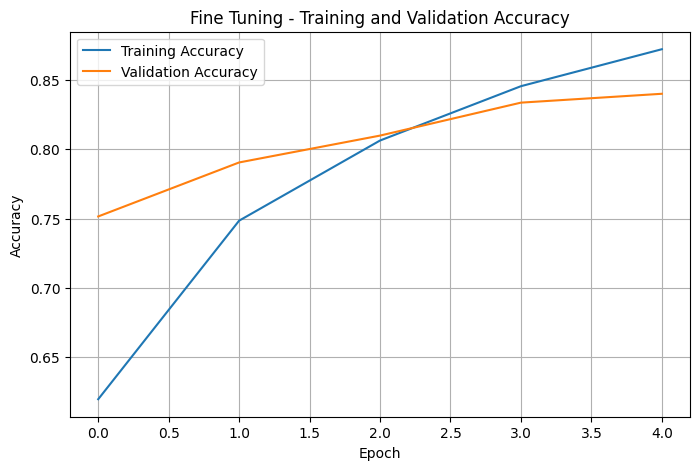

In [24]:
# ============================================
# Task 4: Fine Tuning - Accuracy
# ============================================

plt.figure(figsize=(8, 5))

plt.plot(
    fine_tune_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    fine_tune_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Fine Tuning - Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

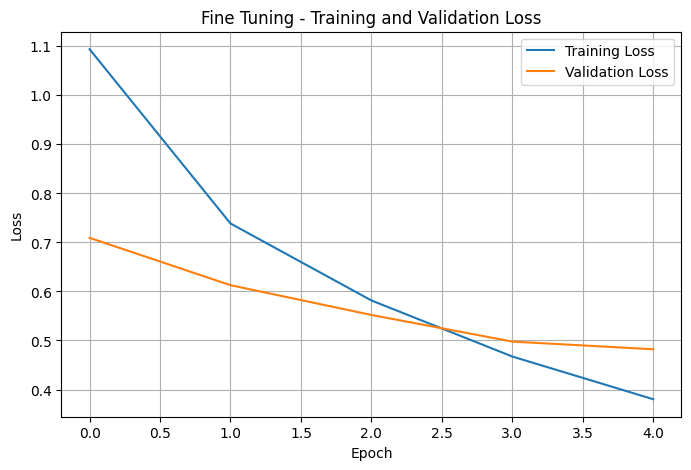

In [25]:
# ============================================
# Task 4: Fine Tuning - Loss
# ============================================

plt.figure(figsize=(8, 5))

plt.plot(
    fine_tune_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    fine_tune_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Fine Tuning - Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

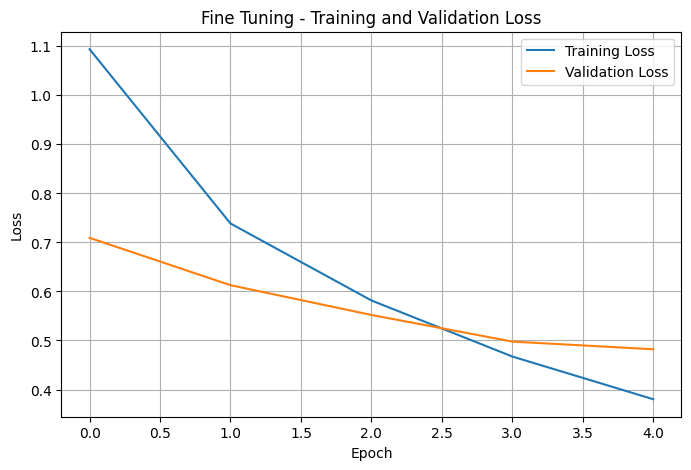

In [26]:
# ============================================
# Task 4: Fine Tuning - Loss
# ============================================

plt.figure(figsize=(8, 5))

plt.plot(
    fine_tune_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    fine_tune_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Fine Tuning - Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [27]:
# ============================================
# Task 5: Model Evaluation - Final Evaluation
# ============================================

final_test_loss, final_test_accuracy = transfer_model.evaluate(
    test_dataset,
    verbose=1
)

print("\nFinal Fine-Tuned Model Performance")
print("===================================")
print("Test Loss     :", final_test_loss)
print("Test Accuracy :", final_test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 61s 196ms/step - accuracy: 0.8401 - loss: 0.4821

Final Fine-Tuned Model Performance
Test Loss     : 0.4820866286754608
Test Accuracy : 0.8400999903678894


In [28]:
# ============================================
# Task 5: Model Evaluation - Final Predictions
# ============================================

final_y_true = []
final_y_pred = []

for images, labels in test_dataset:

    predictions = transfer_model.predict(
        images,
        verbose=0
    )

    final_y_true.extend(
        np.argmax(labels.numpy(), axis=1)
    )

    final_y_pred.extend(
        np.argmax(predictions, axis=1)
    )

final_y_true = np.array(final_y_true)
final_y_pred = np.array(final_y_pred)

print("Final predictions generated successfully.")
print("Number of test samples:", len(final_y_true))

Final predictions generated successfully.
Number of test samples: 10000


In [29]:
# ============================================
# Task 5: Model Evaluation - Final Metrics
# ============================================

final_accuracy = accuracy_score(
    final_y_true,
    final_y_pred
)

final_precision = precision_score(
    final_y_true,
    final_y_pred,
    average="weighted",
    zero_division=0
)

final_recall = recall_score(
    final_y_true,
    final_y_pred,
    average="weighted",
    zero_division=0
)

final_f1 = f1_score(
    final_y_true,
    final_y_pred,
    average="weighted",
    zero_division=0
)

print("============================================")
print("Final Fine-Tuned VGG16 Performance")
print("============================================")
print("Accuracy  :", final_accuracy)
print("Precision :", final_precision)
print("Recall    :", final_recall)
print("F1-Score  :", final_f1)

Final Fine-Tuned VGG16 Performance
Accuracy  : 0.8401
Precision : 0.8476720940092853
Recall    : 0.8401
F1-Score  : 0.8415278477772503


In [30]:
# ============================================
# Task 5: Model Evaluation - Classification Report
# ============================================

print("============================================")
print("Final Classification Report")
print("============================================")

print(
    classification_report(
        final_y_true,
        final_y_pred,
        target_names=class_names,
        zero_division=0
    )
)

Final Classification Report
              precision    recall  f1-score   support

    Airplane       0.87      0.89      0.88      1000
  Automobile       0.92      0.95      0.93      1000
        Bird       0.89      0.74      0.81      1000
         Cat       0.63      0.76      0.69      1000
        Deer       0.88      0.75      0.81      1000
         Dog       0.72      0.80      0.76      1000
        Frog       0.91      0.82      0.86      1000
       Horse       0.88      0.86      0.87      1000
        Ship       0.90      0.92      0.91      1000
       Truck       0.90      0.92      0.91      1000

    accuracy                           0.84     10000
   macro avg       0.85      0.84      0.84     10000
weighted avg       0.85      0.84      0.84     10000



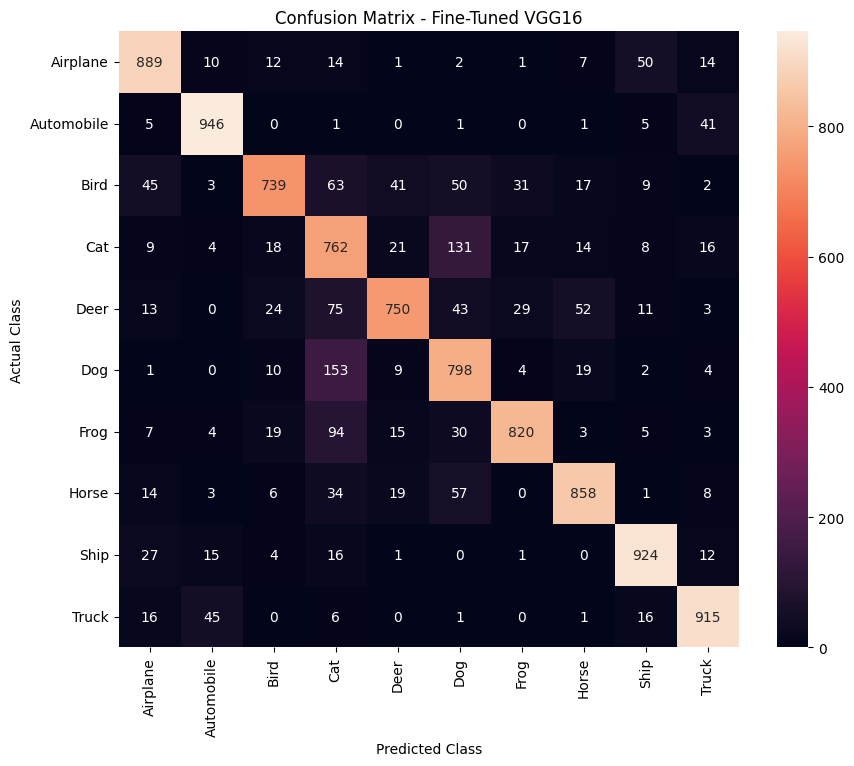

In [31]:
# ============================================
# Task 5: Model Evaluation - Confusion Matrix
# ============================================

final_cm = confusion_matrix(
    final_y_true,
    final_y_pred
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - Fine-Tuned VGG16")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

In [32]:
# ============================================
# Task 5: Comparison Before and After Fine Tuning
# ============================================

print("============================================")
print("Before vs After Fine Tuning")
print("============================================")

print(
    "Before Fine Tuning : {:.4f}".format(
        test_accuracy
    )
)

print(
    "After Fine Tuning  : {:.4f}".format(
        final_test_accuracy
    )
)

improvement = (
    final_test_accuracy - test_accuracy
) * 100

print(
    "Accuracy Improvement : {:.2f}%".format(
        improvement
    )
)

Before vs After Fine Tuning
Before Fine Tuning : 0.6184
After Fine Tuning  : 0.8401
Accuracy Improvement : 22.17%


In [33]:
# ============================================
# Task 5: Results - Performance Summary
# ============================================

total_parameters = transfer_model.count_params()

results = {
    "Training Accuracy": fine_tune_history.history["accuracy"][-1],
    "Testing Accuracy": final_test_accuracy,
    "Precision": final_precision,
    "Recall": final_recall,
    "F1-Score": final_f1,
    "Total Parameters": total_parameters,
    "Training Time (s)": training_time,
    "Fine Tuning Time (s)": fine_tuning_time
}

print("============================================")
print("Performance Summary")
print("============================================")

for metric, value in results.items():
    print(f"{metric:<25}: {value}")

Performance Summary
Training Accuracy        : 0.8722800016403198
Testing Accuracy         : 0.8400999903678894
Precision                : 0.8476720940092853
Recall                   : 0.8401
F1-Score                 : 0.8415278477772503
Total Parameters         : 14781642
Training Time (s)        : 3628.8772699832916
Fine Tuning Time (s)     : 2055.445628643036
